In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(1234)

# Parameters and Uniform Prior

In [2]:
L = 4.0
Npop = 80000
nobs = 150

sigma_x_obs = 1.2
sigma_y_obs = 0.2

sigma_pop_model = 0.40
sigma_pop_truth = 0.40
sigma_rep = 0.12

eps = 1e-4
a = 1.6

smooth_sigma = 1.4

x_pop = rng.uniform(-L, L, Npop)
y_pop = rng.uniform(-L, L, Npop)

# Injected Population

$$
p_{\mathrm{true}}(x, y)
=
\frac{1}{2\pi \sigma_{\mathrm{pop}}^{2}}
\exp\left(
-\frac{x^{2} + y^{2}}{2\sigma_{\mathrm{pop}}^{2}}
\right)
$$

In [3]:
x_true = rng.normal(0.0, sigma_pop_truth, nobs)
y_true = rng.normal(0.0, sigma_pop_truth, nobs)

dx = rng.normal(x_true, sigma_x_obs)
dy = rng.normal(y_true, sigma_y_obs)

dx = dx - np.mean(dx)

x_truth_grid = np.linspace(-4.2, 4.2, 500)

bins = np.linspace(-4.2, 4.2, 120)
bin_width = bins[1] - bins[0]
smooth_width = smooth_sigma * bin_width

truth_x_pdf = norm.pdf(
    x_truth_grid,
    loc=0.0,
    scale=np.sqrt(sigma_pop_truth**2 + sigma_rep**2 + smooth_width**2)
)

# PE Likelihood

$$
p(d_i \mid x, y)
=
\mathcal{N}(d_{x,i} \mid x, \sigma_x)\,
\mathcal{N}(d_{y,i} \mid y, \sigma_y)
$$

In [4]:
event_likes = np.empty((nobs, Npop))

for i in range(nobs):
    event_likes[i] = (
        norm.pdf(dx[i], loc=x_pop, scale=sigma_x_obs)
        * norm.pdf(dy[i], loc=y_pop, scale=sigma_y_obs)
    )

# Population Models

$$
f_1(x,y \mid \mu)
=
\epsilon
+
(1-\epsilon)
\exp\left(
-\frac{(x-\mu)^2}{2\sigma_{\mathrm{pop}}^2}
\right)
\exp\left(
-\frac{y^2}{2\sigma_{\mathrm{pop}}^2}
\right)
$$

and,

$$
f_2(x,y \mid \mu)
=
\epsilon
+
(1-\epsilon)\,\frac{1}{2}
\left[
\exp\left(
-\frac{(x-(\mu-a))^2}{2\sigma_{\mathrm{pop}}^2}
\right)
+
\exp\left(
-\frac{(x-(\mu+a))^2}{2\sigma_{\mathrm{pop}}^2}
\right)
\right]
\exp\left(
-\frac{y^2}{2\sigma_{\mathrm{pop}}^2}
\right).
$$

where $\epsilon$, $\sigma_{\mathrm{pop}}$ and $a$ are fixed.

In [5]:
def unnorm_f1(x, y, mu):
    return (
        eps
        + (1.0 - eps)
        * np.exp(-0.5 * ((x - mu) / sigma_pop_model) ** 2)
        * np.exp(-0.5 * (y / sigma_pop_model) ** 2)
    )

def unnorm_f2(x, y, mu):
    peak_left = np.exp(-0.5 * ((x - (mu - a)) / sigma_pop_model) ** 2)
    peak_right = np.exp(-0.5 * ((x - (mu + a)) / sigma_pop_model) ** 2)

    return (
        eps
        + (1.0 - eps)
        * 0.5 * (peak_left + peak_right)
        * np.exp(-0.5 * (y / sigma_pop_model) ** 2)
    )

# Hierarchical Likelihood

$$
\mathcal{L}_k(\mu)
=
\prod_{i=1}^{N}
\frac{
\displaystyle \int_{-L}^{L} \int_{-L}^{L}
p(d_i \mid x, y)\,
f(x, y \mid \mu)\,dx\,dy
}{
Z_f(\mu)
}
$$

where $L$ is the prior-boundary in the $x$-$y$ plane, $f=f_1$ or $f_2$, and $Z_f(\mu)$ is the normalization of $f$.

In [6]:
mu_grid = np.linspace(-2.0, 2.0, 201)

def hyper_loglike(model):
    logL = np.zeros_like(mu_grid)

    for k, mu in enumerate(mu_grid):

        if model == "f1":
            w = unnorm_f1(x_pop, y_pop, mu)
        else:
            w = unnorm_f2(x_pop, y_pop, mu)

        logZ = np.log(np.mean(w))
        integrals = np.mean(w[None, :] * event_likes, axis=1)

        logL[k] = np.sum(np.log(integrals) - logZ)

    return logL

logL1 = hyper_loglike("f1")
logL2 = hyper_loglike("f2")

logpost1 = logL1 - logsumexp(logL1)
logpost2 = logL2 - logsumexp(logL2)

post1 = np.exp(logpost1)
post2 = np.exp(logpost2)

mu_draws1 = rng.choice(mu_grid, 50000, replace=True, p=post1)
mu_draws2 = rng.choice(mu_grid, 50000, replace=True, p=post2)

mu1_med = np.percentile(mu_draws1, 50)
mu2_med = np.percentile(mu_draws2, 50)

# Posterior Predictive Draws

In [7]:
def draw_ppd(model, n_mu_draws=1000, n_rep_per_mu=1000):

    if model == "f1":
        mu_draws = rng.choice(mu_grid, n_mu_draws, replace=True, p=post1)
    else:
        mu_draws = rng.choice(mu_grid, n_mu_draws, replace=True, p=post2)

    centers = 0.5 * (bins[1:] + bins[:-1])
    hist_draws = []

    for mu in mu_draws:

        if model == "f1":
            w = unnorm_f1(x_pop, y_pop, mu)
        else:
            w = unnorm_f2(x_pop, y_pop, mu)

        p = w / np.sum(w)
        idx = rng.choice(Npop, size=n_rep_per_mu, replace=True, p=p)

        xrep = x_pop[idx] + rng.normal(0.0, sigma_rep, n_rep_per_mu)

        hist, _ = np.histogram(xrep, bins=bins, density=True)
        hist = gaussian_filter1d(hist, smooth_sigma)

        hist_draws.append(hist)

    hist_draws = np.asarray(hist_draws)

    p5 = np.percentile(hist_draws, 5, axis=0)
    p50 = np.percentile(hist_draws, 50, axis=0)
    p95 = np.percentile(hist_draws, 95, axis=0)

    return centers, p5, p50, p95

centers1, p5_1, p50_1, p95_1 = draw_ppd("f1")
centers2, p5_2, p50_2, p95_2 = draw_ppd("f2")

In [8]:
def draw_y_ppd(model, n_mu_draws=1000, n_rep_per_mu=1000):

    if model == "f1":
        mu_draws = rng.choice(mu_grid, n_mu_draws, replace=True, p=post1)
    else:
        mu_draws = rng.choice(mu_grid, n_mu_draws, replace=True, p=post2)

    ycenters = 0.5 * (bins[1:] + bins[:-1])
    hist_draws = []

    for mu in mu_draws:

        if model == "f1":
            w = unnorm_f1(x_pop, y_pop, mu)
        else:
            w = unnorm_f2(x_pop, y_pop, mu)

        p = w / np.sum(w)
        idx = rng.choice(Npop, size=n_rep_per_mu, replace=True, p=p)

        yrep = y_pop[idx] + rng.normal(0.0, sigma_rep, n_rep_per_mu)

        hist, _ = np.histogram(yrep, bins=bins, density=True)
        hist = gaussian_filter1d(hist, smooth_sigma)

        hist_draws.append(hist)

    hist_draws = np.asarray(hist_draws)

    p5 = np.percentile(hist_draws, 5, axis=0)
    p50 = np.percentile(hist_draws, 50, axis=0)
    p95 = np.percentile(hist_draws, 95, axis=0)

    return ycenters, p5, p50, p95


ycenters1, yp5_1, yp50_1, yp95_1 = draw_y_ppd("f1")
ycenters2, yp5_2, yp50_2, yp95_2 = draw_y_ppd("f2")

truth_y_pdf = norm.pdf(
    ycenters1,
    loc=0.0,
    scale=np.sqrt(sigma_pop_truth**2 + sigma_rep**2 + smooth_width**2)
)

In [9]:
ngrid = 300
xx = np.linspace(-L, L, ngrid)
yy = np.linspace(-L, L, ngrid)
X, Y = np.meshgrid(xx, yy)

D1 = unnorm_f1(X, Y, mu1_med)
D2 = unnorm_f2(X, Y, mu2_med)

D1 = D1 / np.max(D1)
D2 = D2 / np.max(D2)

# Plot

## Prior Volume

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

mpl.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "lines.linewidth": 2.5,
})

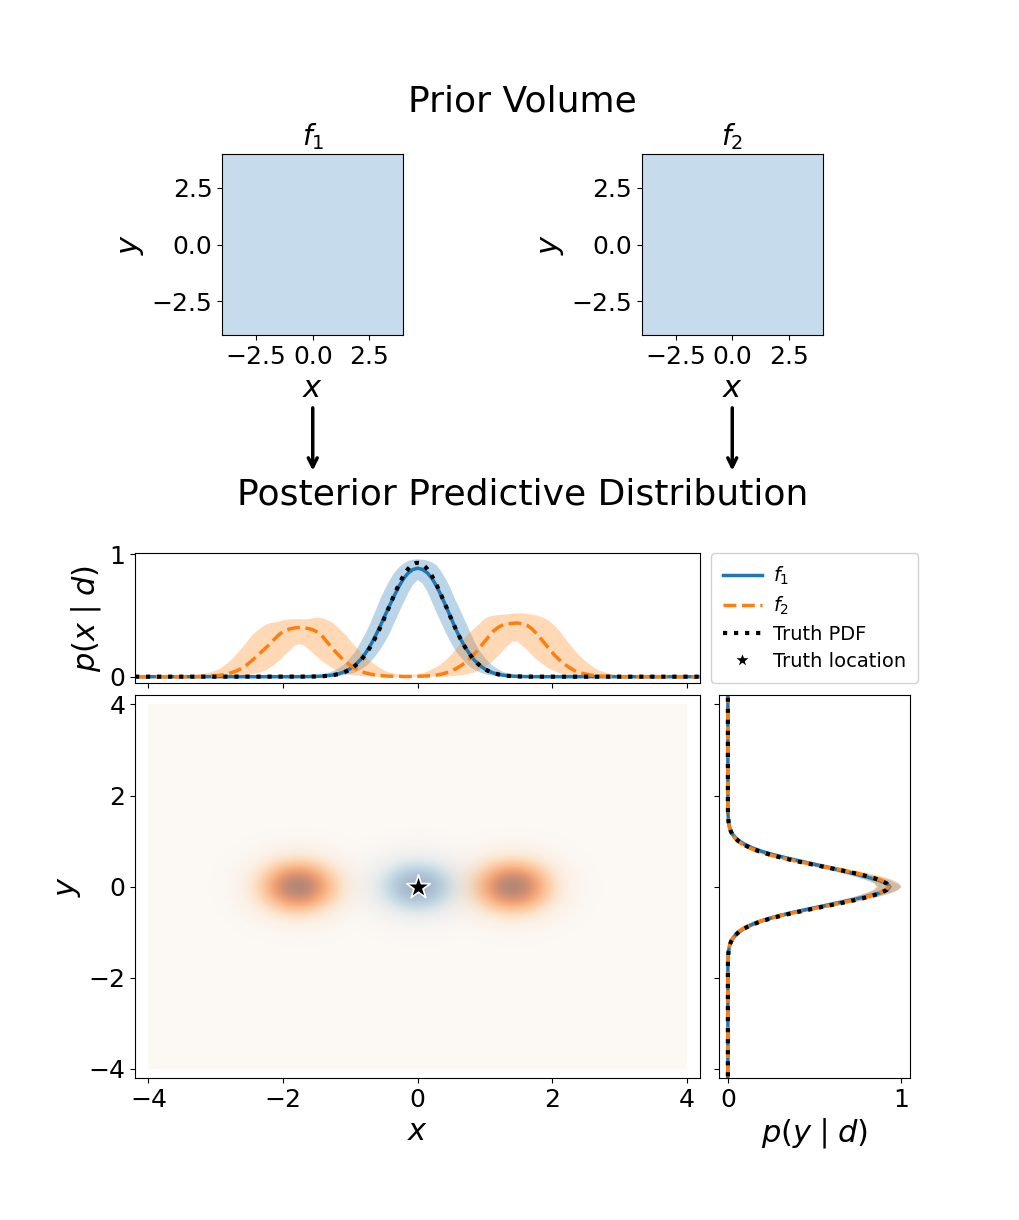

In [11]:
fig = plt.figure(figsize=(10, 12))

outer = fig.add_gridspec(
    3, 1,
    height_ratios=(1.45, 1.2, 4.2),
    hspace=0.12,
)

# Prior volume

gs_prior = outer[0].subgridspec(1, 2, wspace=0.18)

ax_prior1 = fig.add_subplot(gs_prior[0, 0])
ax_prior2 = fig.add_subplot(gs_prior[0, 1], sharex=ax_prior1, sharey=ax_prior1)

for ax, title in zip([ax_prior1, ax_prior2], [r"$f_1$", r"$f_2$"]):
    ax.fill_between([-L, L], -L, L, alpha=0.25)
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(title)

# Posterior predictive

gs_post = outer[2].subgridspec(
    2, 2,
    width_ratios=(4, 1.35),
    height_ratios=(1.35, 4),
    hspace=0.05,
    wspace=0.05,
)

ax_top   = fig.add_subplot(gs_post[0, 0])
ax_main  = fig.add_subplot(gs_post[1, 0])
ax_right = fig.add_subplot(gs_post[1, 1], sharey=ax_main)
ax_leg   = fig.add_subplot(gs_post[0, 1])
ax_leg.axis("off")

# 2D median

ax_main.imshow(D1, extent=[-L, L, -L, L],
               origin="lower", aspect="auto",
               cmap="Blues", alpha=0.75)

ax_main.imshow(D2, extent=[-L, L, -L, L],
               origin="lower", aspect="auto",
               cmap="Oranges", alpha=0.55)

ax_main.scatter([0.0], [0.0],
                marker="*", s=320,
                color="k",
                edgecolor="white", linewidth=1.2)

ax_main.set_xlim(-4.2, 4.2)
ax_main.set_ylim(-4.2, 4.2)
ax_main.set_xlabel(r"$x$")
ax_main.set_ylabel(r"$y$")

# x marginal

l1, = ax_top.plot(centers1, p50_1)
ax_top.fill_between(centers1, p5_1, p95_1, alpha=0.3)

l2, = ax_top.plot(centers2, p50_2, linestyle="--")
ax_top.fill_between(centers2, p5_2, p95_2, alpha=0.3)

l3, = ax_top.plot(x_truth_grid, truth_x_pdf,
                  linestyle=":", linewidth=3, color="k")

ax_top.set_xlim(-4.2, 4.2)
ax_top.set_ylabel(r"$p(x \mid d)$")
ax_top.tick_params(labelbottom=False)

# y marginal
ax_right.plot(yp50_1, ycenters1)
ax_right.fill_betweenx(ycenters1, yp5_1, yp95_1, alpha=0.3)

ax_right.plot(yp50_2, ycenters2, linestyle="--")
ax_right.fill_betweenx(ycenters2, yp5_2, yp95_2, alpha=0.3)

ax_right.plot(truth_y_pdf, ycenters1,
              linestyle=":", linewidth=3, color="k")

ax_right.set_ylim(-4.2, 4.2)
ax_right.set_xlabel(r"$p(y \mid d)$")
ax_right.tick_params(labelleft=False)

# Beautification

star_handle = Line2D(
    [0], [0],
    marker='*',
    color='k',
    linestyle='None',
    markersize=12,
    markeredgecolor='white',
    markeredgewidth=1.0,
)

ax_leg.legend(
    handles=[l1, l2, l3, star_handle],
    labels=[r"$f_1$", r"$f_2$", "Truth PDF", "Truth location"],
    loc="center",
    frameon=True,
    fontsize=14,
    handlelength=2.0,
    handletextpad=0.6,
    borderpad=0.6,
    labelspacing=0.4,
    framealpha=0.9,
    edgecolor="0.8",
)

fig.canvas.draw()

prior_left = ax_prior1.get_position().x0
prior_right = ax_prior2.get_position().x1
prior_top = max(ax_prior1.get_position().y1, ax_prior2.get_position().y1)

post_left = ax_top.get_position().x0
post_right = ax_right.get_position().x1
post_top = ax_top.get_position().y1

post_title_y = post_top + 0.035

fig.text(
    0.5 * (prior_left + prior_right),
    prior_top + 0.03,
    "Prior Volume",
    ha="center",
    va="bottom",
    fontsize=26,
)

fig.text(
    0.5 * (post_left + post_right),
    post_title_y,
    "Posterior Predictive Distribution",
    ha="center",
    va="bottom",
    fontsize=26,
)

ax_anno = fig.add_axes([0, 0, 1, 1])
ax_anno.axis("off")

b1 = ax_prior1.get_position()
b2 = ax_prior2.get_position()

x_shift = 0.01
x1 = 0.5 * (b1.x0 + b1.x1) + x_shift
x2 = 0.5 * (b2.x0 + b2.x1) + x_shift

y_start = min(b1.y0, b2.y0) - 0.05
y_end = post_title_y + 0.04

for x in [x1, x2]:
    ax_anno.annotate(
        "",
        xy=(x, y_end),
        xytext=(x, y_start),
        xycoords="figure fraction",
        textcoords="figure fraction",
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2.5,
        ),
    )

plt.savefig("prior_to_ppd.pdf", dpi=300, bbox_inches="tight")